<a href="https://colab.research.google.com/github/olawaleaboderin/Machine_Learning_Project/blob/main/GxE_Maize_Nigeria_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Genotype × Environment Interactions in Nigerian Maize Breeding Programs

**Course:** Practical Machine Learning — Master's in Green Data Science  
**Institution:** Instituto Superior de Agronomia, Universidade de Lisboa  
**Authors:** [Olawale Serifdeen Aboderin 29206] |[Francis Chinaecherem Uzor	29260]

**Year:** 2026

---

## Table of Contents
1. [Setup and Imports](#1-setup-and-imports)
2. [Data Loading and Exploration](#2-data-loading-and-exploration)
3. [Data Cleaning and Preprocessing](#3-data-cleaning-and-preprocessing)
4. [Feature Engineering](#4-feature-engineering)
5. [Cross-Validation Strategy](#5-cross-validation-strategy)
6. [Model Training and Comparison](#6-model-training-and-comparison)
7. [Results](#7-results)
8. [Location Clustering — Trial Network Optimisation](#8-location-clustering)
9. [Analysis and Discussion](#9-analysis-and-discussion)
10. [Conclusions](#10-conclusions)

## 1. Setup and Imports

In [ ]:
# Prompt: Install required libraries for GxE prediction and location clustering.
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn folium -q

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.stats import pearsonr
import xgboost as xgb

# Visualisation
import folium
from scipy.cluster.hierarchy import dendrogram, linkage

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries loaded successfully')

All libraries loaded successfully


## 2. Data Loading and Exploration

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/olawaleaboderin/Machine_Learning_Project/main/maize_clean.csv')
# Prompt:Generate a dataset overview that summarizes the structure and coverage of the dataset. Display the years,
# locations, agroecological zones, stress conditions, breeding institutions, maturity groups, and seasons represented in the data.

print("=== DATASET OVERVIEW ===")

# Dimensions
print(f"Rows:               {df.shape[0]:,}")
print(f"Columns:            {df.shape[1]}")

# Coverage
print(f"Years:              {sorted(df['YEAR'].unique())}")
print(f"Locations:          {sorted(df['region'].unique())}")
print(f"Agroecological Zones: {df['agro_ecological_zone'].unique().tolist()}")
print(f"Management Conditions:  {df['environment_condition'].unique().tolist()}")
print(f"Breeding Institutions: {df['breeding_institution'].unique().tolist()}")
print(f"Maturity Groups:    {df['maturity_group'].unique().tolist()}")
print(f"Seasons:            {df['season'].unique().tolist()}")

# Genotypes
print(f"Total Genotypes:    {df['Name'].nunique()}")

print("\nGenotypes per institution:")
print(df.groupby('breeding_institution')['Name'].nunique())

print("\nObservations per year:")
print(df['YEAR'].value_counts().sort_index())

print("\nObservations per location:")
print(df['region'].value_counts())

# Missing-value summary
overview = pd.DataFrame({
    'Variable': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Missing Count': df.isnull().sum().values,
    'Missing (%)': (df.isnull().mean() * 100).round(2).values
})

display(overview.sort_values('Missing (%)', ascending=False))

=== DATASET OVERVIEW ===
Rows:               21,330
Columns:            38
Years:              [np.int64(2020), np.int64(2021), np.int64(2022)]
Locations:          ['Ibadan', 'Ilorin', 'Omu-Aran', 'Zaria', 'mokwa']
Agroecological Zones: ['Southern Guinea Savanna', 'Forest–Savanna Transition Zone', 'Northern Guinea Savanna']
Stress Conditions:  ['Optimum', 'Low-N', 'Drought']
Breeding Institutions: ['IAR', 'Unilorin', 'CIMMYT and IITA']
Maturity Groups:    ['Extra-Early', 'Early', 'late', 'Intermediate']
Seasons:            ['rainy', 'Dry']
Total Genotypes:    237

Genotypes per institution:
breeding_institution
CIMMYT and IITA     57
IAR                 80
Unilorin           100
Name: Name, dtype: int64

Observations per year:
YEAR
2020    7110
2021    7110
2022    7110
Name: count, dtype: int64

Observations per location:
region
Omu-Aran    4266
Ibadan      4266
Ilorin      4266
Zaria       4266
mokwa       4266
Name: count, dtype: int64


,Variable,Data Type,Non-Null Count,Missing Count,Missing (%)
34,ear_aspect,float64,21185,145,0.68
29,husk_cover,float64,21325,5,0.02
32,ear_harvested,float64,21325,5,0.02
2,region,object,21330,0,0.00
0,YEAR,int64,21330,0,0.00
1,Country,object,21330,0,0.00
5,environment_condition,object,21330,0,0.00
4,season,object,21330,0,0.00
3,agro_ecological_zone,object,21330,0,0.00
6,latitude,float64,21330,0,0.00


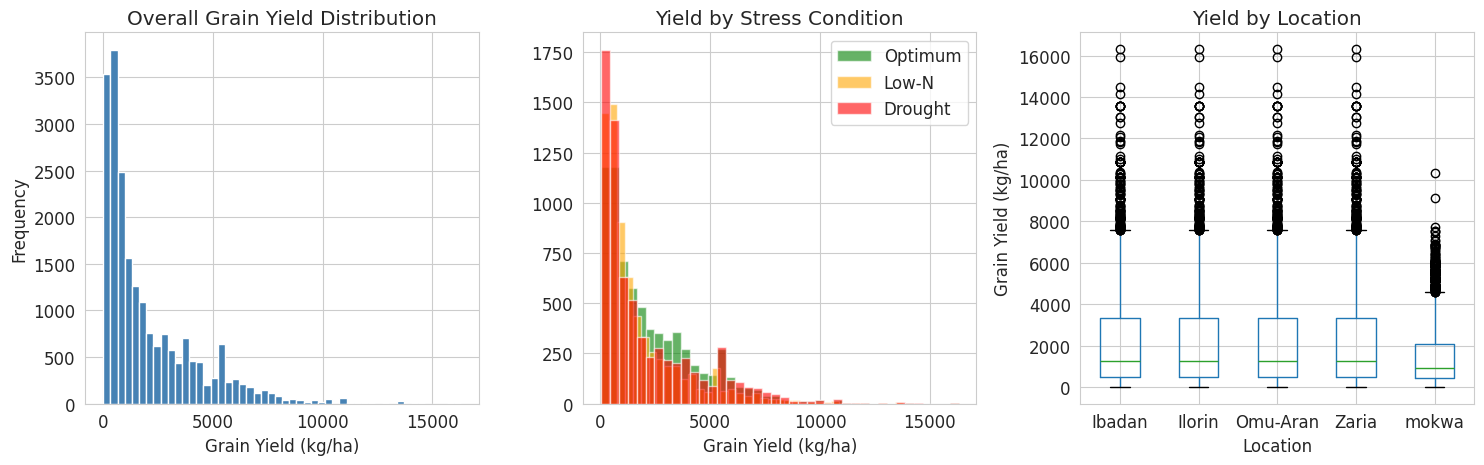

In [ ]:
# Prompt: Plot three charts: overall yield distribution, yield by stress condition,
# and yield boxplot by location.

# --- Yield distributions ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['grain_yield'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Overall Grain Yield Distribution')
axes[0].set_xlabel('Grain Yield (kg/ha)')
axes[0].set_ylabel('Frequency')

for cond, color in zip(['Optimum','Low-N','Drought'], ['green','orange','red']):
    axes[1].hist(df[df['environment_condition']==cond]['grain_yield'],
                 bins=40, alpha=0.6, label=cond, color=color)
axes[1].set_title('Yield by Stress Condition')
axes[1].set_xlabel('Grain Yield (kg/ha)')
axes[1].legend()

df.boxplot(column='grain_yield', by='region', ax=axes[2])
axes[2].set_title('Yield by Location')
axes[2].set_xlabel('Location')
axes[2].set_ylabel('Grain Yield (kg/ha)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('yield_distributions.png', dpi=150, bbox_inches='tight')
plt.show()



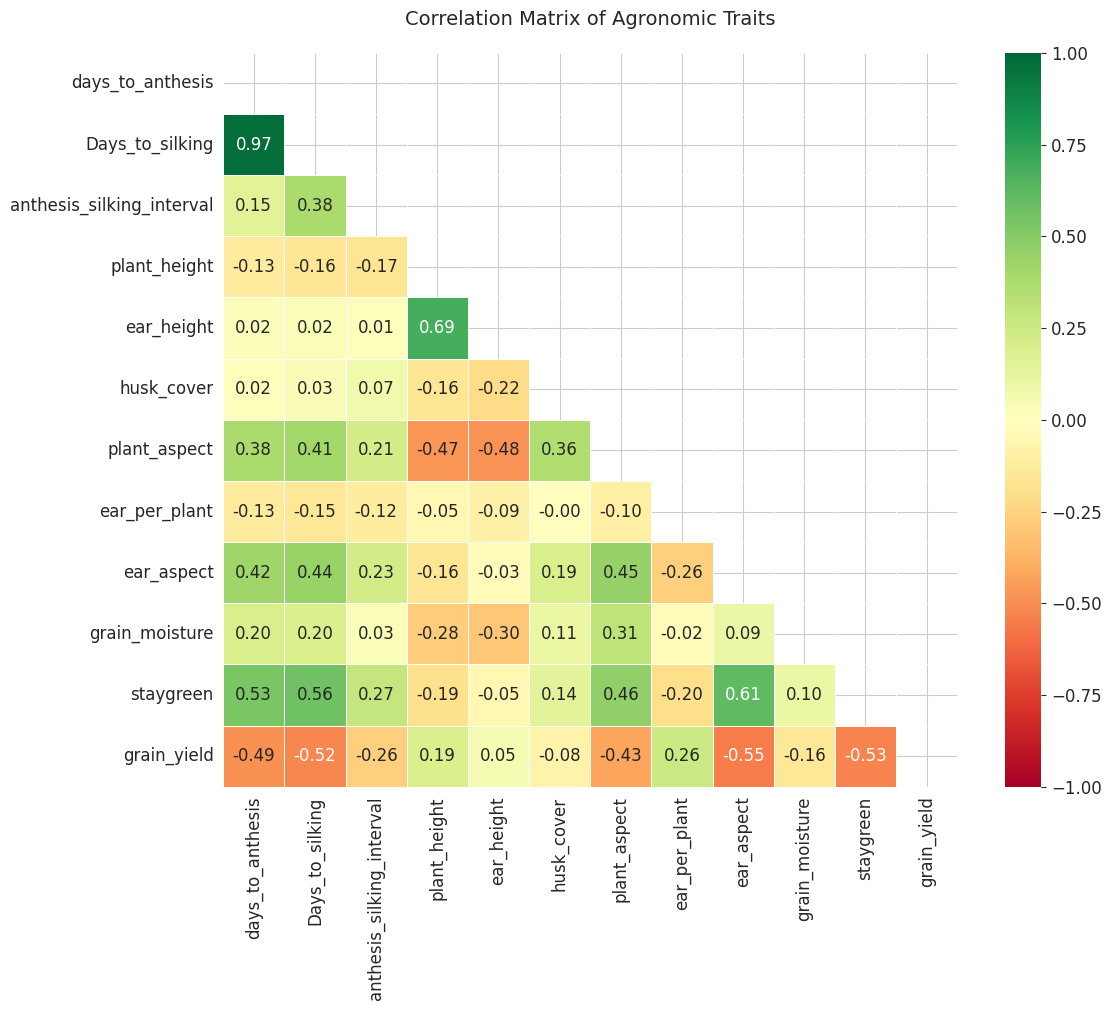

In [ ]:
# Prompt: Create a lower-triangular correlation heatmap for all numeric
# agronomic traits including grain yield, using a red-green diverging colormap.

numeric_cols = ['days_to_anthesis','Days_to_silking','anthesis_silking_interval',
                'plant_height','ear_height','husk_cover','plant_aspect',
                'ear_per_plant','ear_aspect','grain_moisture','staygreen','grain_yield']

corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Agronomic Traits', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Cleaning and Preprocessing

In [ ]:
# Prompt: Standardise location names, create a unique environment_id column,
# impute missing values with column medians, and aggregate replications
# to one row per genotype-environment combination.

# --- Standardise location names ---
df['region'] = df['region'].str.strip().str.title()

# --- Create environment identifier ---
df['environment_id'] = (df['region'] + '_' +
                        df['environment_condition'] + '_' +
                        df['YEAR'].astype(str))

print(f'Unique environments: {df["environment_id"].nunique()}')
print('Sample IDs:', df['environment_id'].unique()[:4].tolist())

# --- Impute missing values with column median ---
# Using assignment (not inplace) for compatibility with newer pandas versions
for col in ['husk_cover', 'ear_harvested', 'ear_aspect', 'staygreen']:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f'Imputed {col} with median: {df[col].median():.2f}')

print(f'\nMissing values after imputation: {df.isnull().sum().sum()}')

# --- Aggregate replications: 2 reps per genotype-environment -> 1 mean row ---
id_cols = ['YEAR','region','agro_ecological_zone','season','environment_condition',
           'latitude','longitude','elevation','rainfall_mm','mean_temperature',
           'soil_type','soil_pH','soil_N_content','soil_P_content','soil_K_content',
           'Name','Pedigree','breeding_institution','maturity_group','environment_id']

agg_cols = ['days_to_anthesis','Days_to_silking','anthesis_silking_interval',
            'plant_height','ear_height','husk_cover','plant_aspect','field_weight',
            'ear_harvested','ear_per_plant','ear_aspect','grain_moisture',
            'grain_yield','staygreen']

df_agg = df.groupby(id_cols)[agg_cols].mean().reset_index()

print(f'Before aggregation: {df.shape}')
print(f'After aggregation:  {df_agg.shape}')
print('Each row = 1 genotype x 1 environment (mean of 2 reps)')

Unique environments: 45
Sample IDs: ['Omu-Aran_Optimum_2020', 'Omu-Aran_Optimum_2021', 'Omu-Aran_Optimum_2022', 'Omu-Aran_Low-N_2020']
Imputed husk_cover with median: 2.00
Imputed ear_harvested with median: 6.00
Imputed ear_aspect with median: 3.50
Imputed staygreen with median: 4.00

Missing values after imputation: 0
Before aggregation: (21330, 39)
After aggregation:  (10680, 34)
Each row = 1 genotype x 1 environment (mean of 2 reps)


## 4. Feature Engineering

In [ ]:
# Prompt: Engineer six features: genotype mean yield, environment mean yield,
# location mean yield, Stress Tolerance Index (STI), yield stability CV,
# and encode all categorical variables.

# --- Main effect features ---
df_agg['geno_mean_yield'] = df_agg.groupby('Name')['grain_yield'].transform('mean')
df_agg['env_mean_yield']  = df_agg.groupby('environment_id')['grain_yield'].transform('mean')
df_agg['loc_mean_yield']  = df_agg.groupby('region')['grain_yield'].transform('mean')
print('Mean yield features added')

# --- Stress Tolerance Index (STI) ---
# STI = (yield_stress x yield_optimum) / (mean_optimum^2)
# Higher STI = better stress tolerance
opt = (df_agg[df_agg['environment_condition']=='Optimum']
       [['Name','region','YEAR','grain_yield']]
       .rename(columns={'grain_yield':'yield_optimum'}))
df_agg = df_agg.merge(opt, on=['Name','region','YEAR'], how='left')

mean_opt = (df_agg[df_agg['environment_condition']=='Optimum']
            .groupby(['region','YEAR'])['grain_yield']
            .mean().rename('mean_opt_yield').reset_index())
df_agg = df_agg.merge(mean_opt, on=['region','YEAR'], how='left')

df_agg['stress_tolerance_index'] = (
    (df_agg['grain_yield'] * df_agg['yield_optimum']) /
    (df_agg['mean_opt_yield'] ** 2)
)
df_agg.loc[df_agg['environment_condition']=='Optimum', 'stress_tolerance_index'] = 1.0

print('Stress Tolerance Index calculated')
print(df_agg[['Name','region','environment_condition',
              'grain_yield','stress_tolerance_index']].head(6))

# --- Yield stability (coefficient of variation per genotype) ---
df_agg['geno_yield_cv'] = df_agg.groupby('Name')['grain_yield'].transform(
    lambda x: x.std() / x.mean() * 100)

# --- Encode categorical variables ---
zone_map      = {'Northern Guinea Savanna':0,'Southern Guinea Savanna':1,
                 'Forest–Savanna Transition Zone':2}
condition_map = {'Drought':0,'Low-N':1,'Optimum':2}
maturity_map  = {'Extra-Early':0,'Early':1,'Intermediate':2,'late':3}
season_map    = {'Dry':0,'rainy':1}
inst_map      = {'IAR':0,'Unilorin':1,'CIMMYT and IITA':2}

df_agg['zone_enc']        = df_agg['agro_ecological_zone'].map(zone_map)
df_agg['condition_enc']   = df_agg['environment_condition'].map(condition_map)
df_agg['maturity_enc']    = df_agg['maturity_group'].map(maturity_map)
df_agg['season_enc']      = df_agg['season'].map(season_map)
df_agg['institution_enc'] = df_agg['breeding_institution'].map(inst_map)

le_geno   = LabelEncoder()
le_region = LabelEncoder()
df_agg['geno_enc']   = le_geno.fit_transform(df_agg['Name'])
df_agg['region_enc'] = le_region.fit_transform(df_agg['region'])

# --- Features selection ---
FEATURES = [
    'geno_enc','institution_enc','maturity_enc',
    'region_enc','zone_enc','condition_enc','season_enc','YEAR',
    'latitude','longitude','elevation','rainfall_mm','mean_temperature',
    'soil_pH','soil_N_content','soil_P_content','soil_K_content',
    'days_to_anthesis','Days_to_silking','anthesis_silking_interval',
    'plant_height','ear_height','husk_cover','plant_aspect',
    'ear_per_plant','ear_aspect','grain_moisture','staygreen',
    'geno_mean_yield','env_mean_yield','loc_mean_yield',
    'stress_tolerance_index','geno_yield_cv'
]
for col in FEATURES:
    if df_agg[col].isnull().sum() > 0:
        df_agg[col] = df_agg[col].fillna(df_agg[col].median())

TARGET = 'grain_yield'
X = df_agg[FEATURES].copy()
y = df_agg[TARGET].copy()

print(f'Feature matrix: {X.shape}  |  Target: {y.shape}')
print(f'NaN in features: {X.isnull().sum().sum()} (should be 0)')
print(f'\nFeatures ({len(FEATURES)}):')
for f in FEATURES: print(f'  - {f}')



Mean yield features added
Stress Tolerance Index calculated
        Name  region environment_condition  grain_yield  \
0  ILOMAZ-01  Ibadan               Drought     2446.100   
1  ILOMAZ-02  Ibadan               Drought     2758.275   
2  ILOMAZ-03  Ibadan               Drought     2838.800   
3  ILOMAZ-04  Ibadan               Drought     2990.210   
4  ILOMAZ-05  Ibadan               Drought     1750.455   
5  ILOMAZ-06  Ibadan               Drought     3579.555   

   stress_tolerance_index  
0                0.885088  
1                3.849728  
2                0.427826  
3                2.117599  
4                0.231987  
5                2.505448  
Feature matrix: (10710, 33)  |  Target: (10710,)
NaN in features: 0 (should be 0)

Features (33):
  - geno_enc
  - institution_enc
  - maturity_enc
  - region_enc
  - zone_enc
  - condition_enc
  - season_enc
  - YEAR
  - latitude
  - longitude
  - elevation
  - rainfall_mm
  - mean_temperature
  - soil_pH
  - soil_N_content
  -

## 5. Cross-Validation Strategy

In [ ]:
# Prompt: Define three CV schemes: CV1 random 5-fold, CV2 leave-one-environment-out,
# CV0 leave-one-genotype-group-out.

# CV1: Random 5-fold — general predictive accuracy
cv1 = KFold(n_splits=5, shuffle=True, random_state=42)

# CV2: Leave-one-environment-out — predicting a completely new location
cv2_groups = df_agg['environment_id'].values
cv2 = GroupKFold(n_splits=df_agg['environment_id'].nunique())

# CV0: Leave-one-genotype-group-out — predicting a brand new variety
cv0_groups = df_agg['Name'].values
cv0 = GroupKFold(n_splits=10)

print('Cross-validation schemes defined:')
print(f'  CV1 (random):              5 folds')
print(f'  CV2 (leave-environment):   {df_agg["environment_id"].nunique()} folds')
print(f'  CV0 (leave-genotype):      10 folds')

Cross-validation schemes defined:
  CV1 (random):              5 folds
  CV2 (leave-environment):   45 folds
  CV0 (leave-genotype):      10 folds


## 6. Model Training and Comparison

In [ ]:
# Prompt: Define a scikit-learn compatible AMMI-2 regressor as classical baseline.
# AMMI decomposes yield into grand mean + genotype effect + environment effect
# + rank-2 SVD interaction. Include as first model in the comparison.

from sklearn.base import BaseEstimator, RegressorMixin

class AMMI2Regressor(BaseEstimator, RegressorMixin):

    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, X, y):
        # Column positions in FEATURES list:
        # geno_enc=0, region_enc=3, condition_enc=5
        if hasattr(X, 'iloc'):
            geno_idx = X.iloc[:, 0].astype(int).values
            env_idx  = (X.iloc[:, 3].astype(int).values * 10 +
                        X.iloc[:, 5].astype(int).values)
            y_vals   = y.values if hasattr(y, 'values') else y
        else:
            geno_idx = X[:, 0].astype(int)
            env_idx  = X[:, 3].astype(int) * 10 + X[:, 5].astype(int)
            y_vals   = y

        self.grand_mean_   = float(np.mean(y_vals))
        self.geno_effects_ = {}
        self.env_effects_  = {}

        for g in np.unique(geno_idx):
            self.geno_effects_[g] = float(np.mean(y_vals[geno_idx==g])) - self.grand_mean_
        for e in np.unique(env_idx):
            self.env_effects_[e]  = float(np.mean(y_vals[env_idx==e]))  - self.grand_mean_

        residuals = np.array([
            y_vals[i] - self.grand_mean_
            - self.geno_effects_.get(geno_idx[i], 0)
            - self.env_effects_.get(env_idx[i], 0)
            for i in range(len(y_vals))
        ])

        geno_list     = sorted(np.unique(geno_idx))
        env_list      = sorted(np.unique(env_idx))
        self.g_map_   = {g: i for i, g in enumerate(geno_list)}
        self.e_map_   = {e: i for i, e in enumerate(env_list)}

        R      = np.zeros((len(geno_list), len(env_list)))
        counts = np.zeros_like(R)
        for i in range(len(y_vals)):
            gi = self.g_map_[geno_idx[i]]
            ei = self.e_map_[env_idx[i]]
            R[gi, ei]      += residuals[i]
            counts[gi, ei] += 1
        R[counts > 0] /= counts[counts > 0]

        U, s, Vt     = np.linalg.svd(R, full_matrices=False) # Changed np_svd to np.linalg.svd
        self.U_      = U[:, :self.n_components]
        self.s_      = s[:self.n_components]
        self.Vt_     = Vt[:self.n_components, :]

        var_exp = np.cumsum(s**2 / np.sum(s**2) * 100)
        print(f'  [AMMI-{self.n_components}] Interaction variance explained: '
              f'{var_exp[self.n_components-1]:.1f}%')
        return self

    def predict(self, X):
        if hasattr(X, 'iloc'):
            geno_idx = X.iloc[:, 0].astype(int).values
            env_idx  = (X.iloc[:, 3].astype(int).values * 10 +
                        X.iloc[:, 5].astype(int).values)
        else:
            geno_idx = X[:, 0].astype(int)
            env_idx  = X[:, 3].astype(int) * 10 + X[:, 5].astype(int)

        preds = np.zeros(len(X))
        for i in range(len(X)):
            g    = geno_idx[i]
            e    = env_idx[i]
            pred = (self.grand_mean_
                    + self.geno_effects_.get(g, 0)
                    + self.env_effects_.get(e, 0))
            if g in self.g_map_ and e in self.e_map_:
                gi    = self.g_map_[g]
                ei    = self.e_map_[e]
                pred += float(np.sum(self.s_ * self.U_[gi,:] * self.Vt_[:,ei]))
            preds[i] = pred
        return preds

print('AMMI2Regressor class defined successfully')

AMMI2Regressor class defined successfully


In [ ]:
# Prompt: Define helper functions for cross-validated evaluation. Skip
# StandardScaler for AMMI-2 since it uses encoded integer indices directly.

def evaluate_predictions(y_true, y_pred, model_name, cv_name):
    """Compute RMSE, R-squared, and Pearson r."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    r, _ = pearsonr(y_true, y_pred)
    return {
        'Model':        model_name,
        'CV Scheme':    cv_name,
        'RMSE (kg/ha)': round(rmse, 2),
        'R²':           round(r2, 4),
        'Pearson r':    round(r, 4)
    }

def run_cv(model, X, y, cv, groups=None, model_name='Model', cv_name='CV'):
    """Wrap model in pipeline and run cross-validated prediction."""
    # AMMI-2 uses integer-encoded columns directly; scaling would distort them
    if model_name == 'AMMI-2':
        pipeline = Pipeline([('model', model)])
    else:
        pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
    y_pred = cross_val_predict(pipeline, X, y, cv=cv, groups=groups)
    return evaluate_predictions(y, y_pred, model_name, cv_name), y_pred

print('Helper functions defined')

Helper functions defined


In [ ]:
# Prompt: Define all six models: AMMI-2 as classical baseline, then Ridge,
# Lasso, SVR, Random Forest, and XGBoost as ML models.

models = {
    # Classical baseline
    'AMMI-2':       AMMI2Regressor(n_components=2),

    # Linear ML models
    'Ridge':        Ridge(alpha=1.0),
    'Lasso':        Lasso(alpha=1.0, max_iter=5000),

    # Non-linear ML models
    'SVR':          SVR(kernel='rbf', C=10, epsilon=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10,
                                          min_samples_leaf=5,
                                          random_state=42, n_jobs=-1),
    'XGBoost':      xgb.XGBRegressor(n_estimators=300, max_depth=6,
                                      learning_rate=0.05, subsample=0.8,
                                      colsample_bytree=0.8,
                                      random_state=42, n_jobs=-1)
}

print(f'{len(models)} models defined:')
print('  Classical baseline: AMMI-2')
print('  ML models:', [k for k in models.keys() if k != 'AMMI-2'])

6 models defined:
  Classical baseline: AMMI-2
  ML models: ['Ridge', 'Lasso', 'SVR', 'RandomForest', 'XGBoost']


In [ ]:
# Prompt: Run all six models across all three CV schemes and store results.

all_results     = []
all_predictions = {}

cv_schemes = {
    'CV1 (Random)':     (cv1, None),
    'CV2 (Leave-Env)':  (cv2, cv2_groups),
    'CV0 (Leave-Geno)': (cv0, cv0_groups)
}

print('Running all models across all CV schemes...')
print('=' * 60)

for model_name, model in models.items():
    all_predictions[model_name] = {}
    print(f'\n{model_name}:')
    for cv_name, (cv_obj, groups) in cv_schemes.items():
        print(f'  Running {cv_name}...', end=' ')
        metrics, y_pred = run_cv(model, X, y, cv=cv_obj,
                                  groups=groups,
                                  model_name=model_name,
                                  cv_name=cv_name)
        all_results.append(metrics)
        all_predictions[model_name][cv_name] = y_pred
        print(f'RMSE={metrics["RMSE (kg/ha)"]:.1f}  '
              f'R²={metrics["R²"]:.3f}  '
              f'r={metrics["Pearson r"]:.3f}')

results_df = pd.DataFrame(all_results)
print()
print('=' * 60)
print(f'All models completed! ({len(results_df)} combinations: '
      f'{len(models)} models x 3 CV schemes)')

Running all models across all CV schemes...

AMMI-2:
  Running CV1 (Random)...   [AMMI-2] Interaction variance explained: 27.9%
  [AMMI-2] Interaction variance explained: 27.8%
  [AMMI-2] Interaction variance explained: 27.5%
  [AMMI-2] Interaction variance explained: 28.0%
  [AMMI-2] Interaction variance explained: 30.1%
RMSE=1773.3  R²=0.013  r=0.272
  Running CV2 (Leave-Env)...   [AMMI-2] Interaction variance explained: 32.1%
  [AMMI-2] Interaction variance explained: 30.5%
  [AMMI-2] Interaction variance explained: 30.4%
  [AMMI-2] Interaction variance explained: 31.2%
  [AMMI-2] Interaction variance explained: 31.8%
  [AMMI-2] Interaction variance explained: 30.9%
  [AMMI-2] Interaction variance explained: 32.3%
  [AMMI-2] Interaction variance explained: 35.7%
  [AMMI-2] Interaction variance explained: 31.1%
  [AMMI-2] Interaction variance explained: 31.1%
  [AMMI-2] Interaction variance explained: 31.0%
  [AMMI-2] Interaction variance explained: 30.8%
  [AMMI-2] Interaction varia

In [ ]:
# Prompt: Train XGBoost on the full dataset and save the model, scaler,
# and label encoders to disk for use in the Streamlit deployment app.

import joblib

# Train XGBoost on full dataset (for deployment)
scaler_full = StandardScaler()
X_scaled    = scaler_full.fit_transform(X)

xgb_model_full = xgb.XGBRegressor(n_estimators=300, max_depth=6,
                                    learning_rate=0.05, subsample=0.8,
                                    colsample_bytree=0.8, random_state=42)
xgb_model_full.fit(X_scaled, y)

# Save to disk
joblib.dump(xgb_model_full, 'xgb_model.pkl')
joblib.dump(scaler_full,    'scaler.pkl')
joblib.dump(le_geno,        'le_geno.pkl')
joblib.dump(le_region,      'le_region.pkl')

print('Models saved:')
print('  xgb_model.pkl, scaler.pkl, le_geno.pkl, le_region.pkl')

Models saved:
  xgb_model.pkl, scaler.pkl, le_geno.pkl, le_region.pkl


In [ ]:
# Download saved files from Colab
from google.colab import files
files.download('xgb_model.pkl')
files.download('scaler.pkl')
files.download('le_geno.pkl')
files.download('le_region.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Results

=== MODEL PERFORMANCE COMPARISON ===

RMSE (kg/ha) — lower is better:
CV Scheme     CV0 (Leave-Geno)  CV1 (Random)  CV2 (Leave-Env)
Model                                                        
AMMI-2                  1663.8        1773.4           1885.5
Lasso                   1145.5        1146.9           1174.8
RandomForest             989.8         994.0           1052.0
Ridge                   1145.1        1146.6           1177.5
SVR                     1303.0        1322.6           1336.0
XGBoost                  948.7         959.1           1023.7

R² — higher is better:
CV Scheme     CV0 (Leave-Geno)  CV1 (Random)  CV2 (Leave-Env)
Model                                                        
AMMI-2                   0.131         0.013           -0.116
Lasso                    0.588         0.587            0.567
RandomForest             0.692         0.690            0.653
Ridge                    0.588         0.587            0.565
SVR                      0.467        

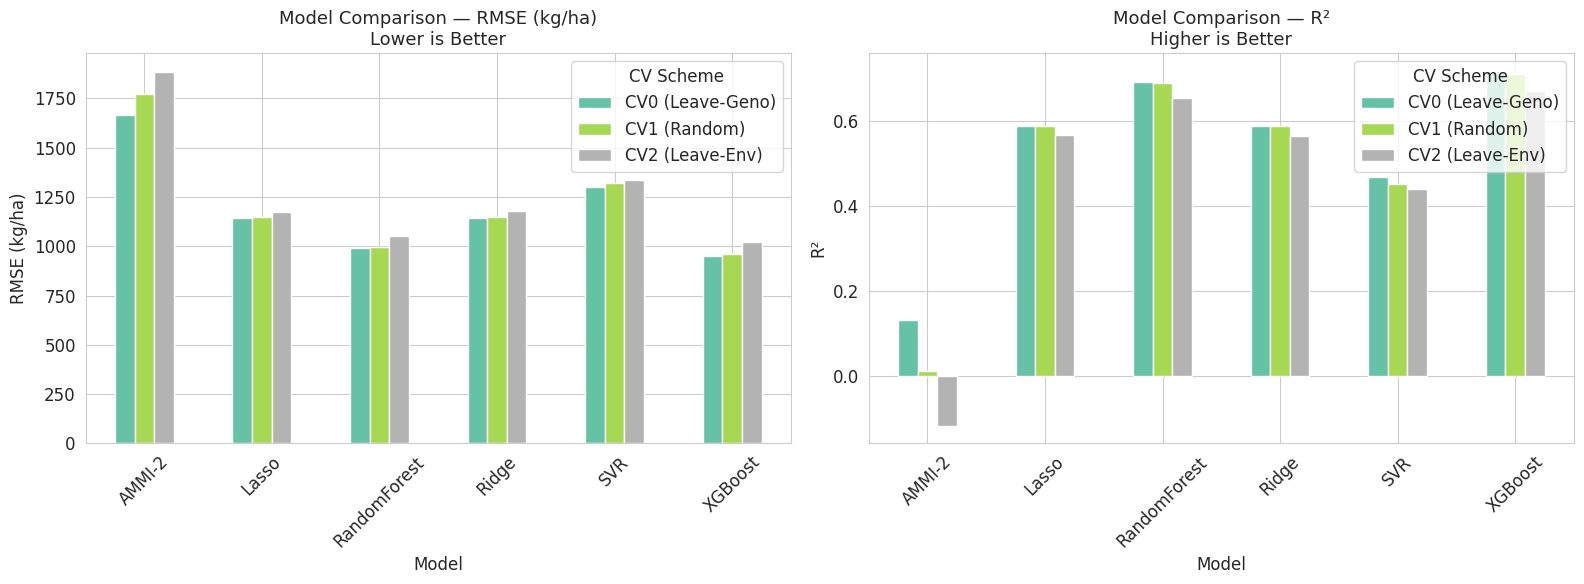

Saved: model_comparison.png


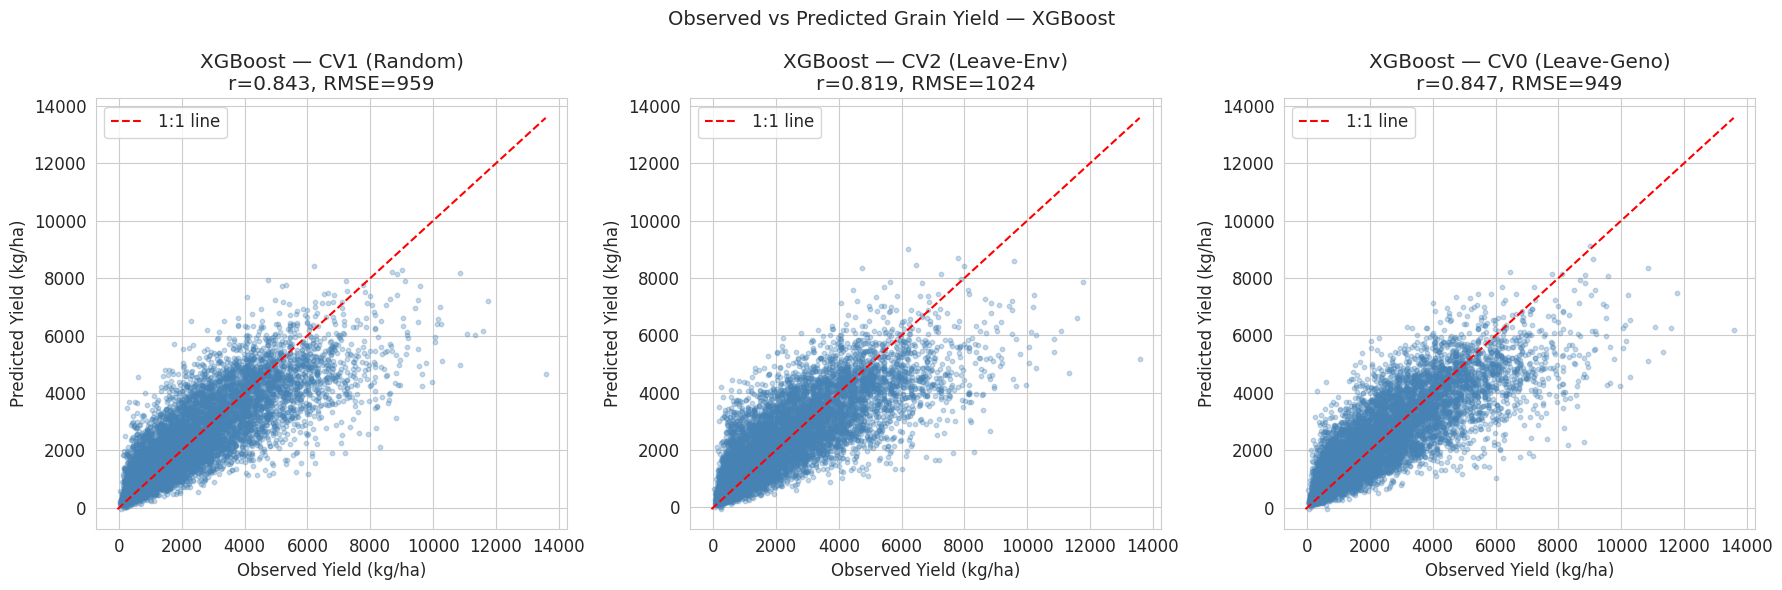

Saved: observed_vs_predicted.png


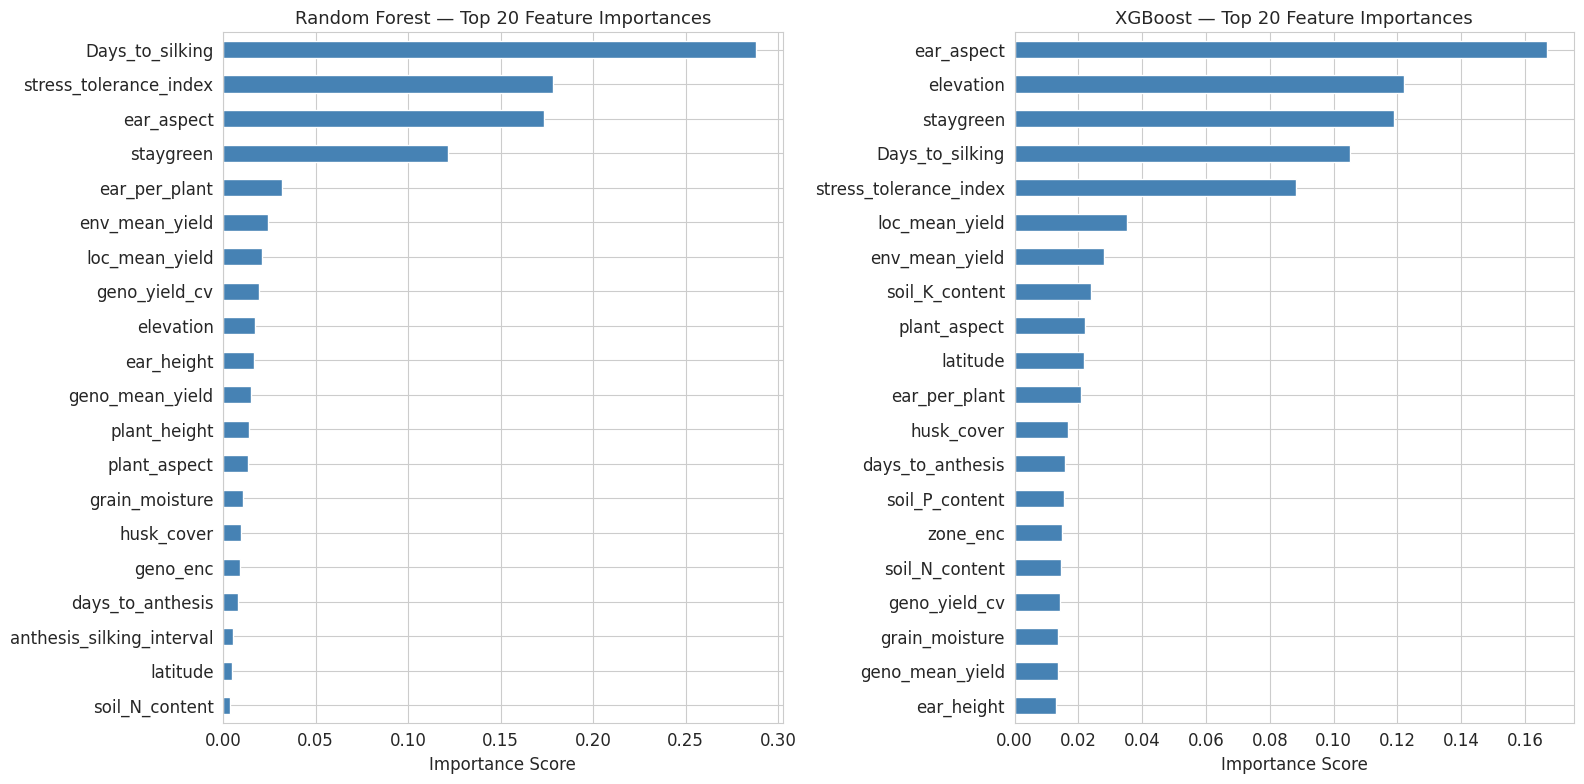

Saved: feature_importance.png


In [ ]:
# Prompt: Print RMSE and R-squared pivot tables comparing all models
# across CV schemes, and identify the best model per CV scheme.
# Create bar charts comparing RMSE and R-squared across all models
# and CV schemes, scatter plots of observed vs predicted for the best model,
# and feature importance charts for Random Forest and XGBoost.

print('=== MODEL PERFORMANCE COMPARISON ===')
print()

rmse_pivot = results_df.pivot(index='Model', columns='CV Scheme', values='RMSE (kg/ha)')
r2_pivot   = results_df.pivot(index='Model', columns='CV Scheme', values='R²')

print('RMSE (kg/ha) — lower is better:')
print(rmse_pivot.round(1))
print()
print('R² — higher is better:')
print(r2_pivot.round(3))
print()
print('Best model per CV scheme (lowest RMSE):')
for cv in results_df['CV Scheme'].unique():
    sub  = results_df[results_df['CV Scheme']==cv]
    best = sub.loc[sub['RMSE (kg/ha)'].idxmin()]
    print(f"  {cv}: {best['Model']} "
          f"(RMSE={best['RMSE (kg/ha)']:.1f}, R²={best['R²']:.3f})")


# ---  Model comparison bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rmse_pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Model Comparison — RMSE (kg/ha)\nLower is Better', fontsize=13)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE (kg/ha)')
axes[0].legend(title='CV Scheme')
axes[0].tick_params(axis='x', rotation=45)

r2_pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Model Comparison — R²\nHigher is Better', fontsize=13)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R²')
axes[1].legend(title='CV Scheme')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

# --- Observed vs Predicted — Best ML model (XGBoost) across CV schemes ---
best_model_name = 'XGBoost'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cv_name in zip(axes, ['CV1 (Random)','CV2 (Leave-Env)','CV0 (Leave-Geno)']):
    y_pred    = all_predictions[best_model_name][cv_name]
    r, _      = pearsonr(y, y_pred)
    rmse_val  = np.sqrt(mean_squared_error(y, y_pred))
    ax.scatter(y, y_pred, alpha=0.3, s=10, color='steelblue')
    lim = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='1:1 line')
    ax.set_xlabel('Observed Yield (kg/ha)')
    ax.set_ylabel('Predicted Yield (kg/ha)')
    ax.set_title(f'{best_model_name} — {cv_name}\nr={r:.3f}, RMSE={rmse_val:.0f}')
    ax.legend()

plt.suptitle(f'Observed vs Predicted Grain Yield — {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('observed_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: observed_vs_predicted.png')

# --- Feature importance — Random Forest and XGBoost retrained on full data ---
rf_model  = RandomForestRegressor(n_estimators=200, max_depth=10,
                                   min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_scaled, y)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, model_obj, label in [
    (axes[0], rf_model,       'Random Forest'),
    (axes[1], xgb_model_full, 'XGBoost')
]:
    imp = pd.Series(model_obj.feature_importances_, index=FEATURES)
    imp.sort_values(ascending=True).tail(20).plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{label} — Top 20 Feature Importances', fontsize=13)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## 8. Location Clustering — Trial Network Optimisation

In [ ]:
# Prompt: Build a location x genotype performance matrix and determine the
# optimal number of location clusters using K-Means and Silhouette Score.

location_matrix = df_agg.pivot_table(
    index='region', columns='Name',
    values='grain_yield', aggfunc='mean')
location_matrix = location_matrix.fillna(location_matrix.mean())

print(f'Location performance matrix: {location_matrix.shape}')
print('Locations:', location_matrix.index.tolist())

scaler_loc      = StandardScaler()
loc_scaled      = scaler_loc.fit_transform(location_matrix)

silhouette_scores = []
k_range = range(2, 5)
for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(loc_scaled)
    score  = silhouette_score(loc_scaled, labels)
    silhouette_scores.append(score)
    print(f'k={k}: Silhouette Score = {score:.4f}')

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f'\nOptimal number of clusters: {optimal_k}')

Location performance matrix: (5, 237)
Locations: ['Ibadan', 'Ilorin', 'Mokwa', 'Omu-Aran', 'Zaria']
k=2: Silhouette Score = 0.1282
k=3: Silhouette Score = 0.0196
k=4: Silhouette Score = 0.0091

Optimal number of clusters: 2


Location cluster assignments:
   Location  Cluster  Latitude  Longitude
0    Ibadan        1    7.3775      3.947
1    Ilorin        1    8.5000      4.550
2     Mokwa        0    9.3000      5.050
3  Omu-Aran        1    8.1400      5.100
4     Zaria        1   11.0667      7.700


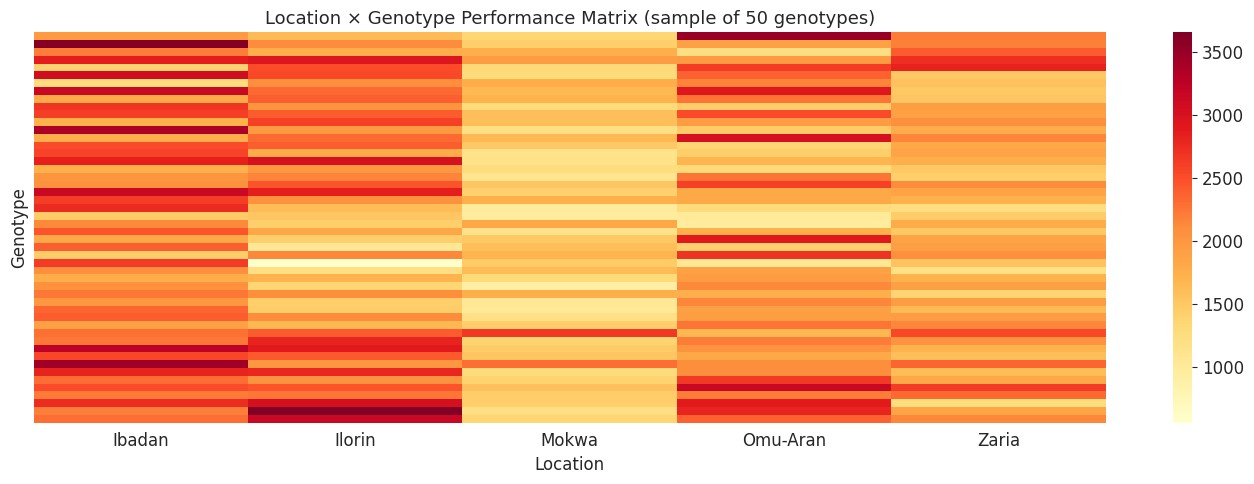

Saved: nigeria_location_clusters.html


In [ ]:
# Prompt: Cluster locations with optimal k, map them on Nigeria using folium,
# visualise with a heatmap and dendrogram.

# --- K-Means clustering ---
km_final          = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
location_clusters = km_final.fit_predict(loc_scaled)

coords = df_agg.groupby('region')[['latitude','longitude']].mean().reset_index()
coords.columns = ['Location','Latitude','Longitude']

location_cluster_df = pd.DataFrame({
    'Location': location_matrix.index,
    'Cluster':  location_clusters
}).merge(coords, on='Location')

print('Location cluster assignments:')
print(location_cluster_df)

# --- Heatmap ---
plt.figure(figsize=(14, 5))
sns.heatmap(location_matrix.T.head(50), cmap='YlOrRd',
            linewidths=0, yticklabels=False)
plt.title('Location × Genotype Performance Matrix (sample of 50 genotypes)', fontsize=13)
plt.xlabel('Location')
plt.ylabel('Genotype')
plt.tight_layout()
plt.savefig('location_genotype_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Nigeria map ---
cluster_colors = ['red','blue','green','purple','orange']
nigeria_map    = folium.Map(location=[9.5, 8.0], zoom_start=6,
                             tiles='CartoDB positron')
for _, row in location_cluster_df.iterrows():
    color = cluster_colors[row['Cluster']]
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=15, color=color, fill=True, fill_color=color, fill_opacity=0.8,
        popup=folium.Popup(f"<b>{row['Location']}</b><br>Cluster: {row['Cluster']}",
                           max_width=200),
        tooltip=f"{row['Location']} (Cluster {row['Cluster']})"
    ).add_to(nigeria_map)
nigeria_map.save('nigeria_location_clusters.html')
print('Saved: nigeria_location_clusters.html')
nigeria_map

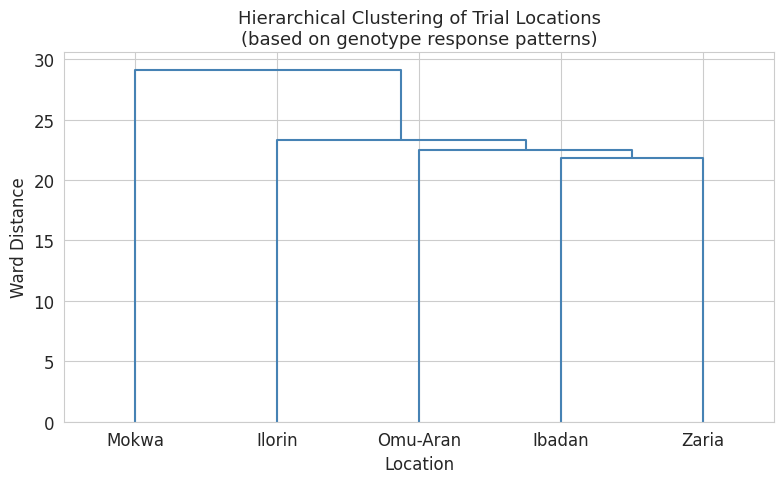

Saved: location_dendrogram.png


In [ ]:
# --- Hierarchical clustering dendrogram ---
linked = linkage(loc_scaled, method='ward')
plt.figure(figsize=(8, 5))
dendrogram(linked, labels=location_matrix.index.tolist(),
           color_threshold=0, above_threshold_color='steelblue')
plt.title('Hierarchical Clustering of Trial Locations\n(based on genotype response patterns)', fontsize=13)
plt.xlabel('Location')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('location_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: location_dendrogram.png')

In [ ]:
# Prompt: Drop each location one at a time, retrain XGBoost, and measure
# how much RMSE changes to quantify each location's unique contribution.

baseline_rmse = results_df[
    (results_df['Model']=='XGBoost') &
    (results_df['CV Scheme']=='CV1 (Random)')
]['RMSE (kg/ha)'].values[0]

print('=== TRIAL NETWORK OPTIMISATION ===')
print(f'Baseline RMSE (all locations): {baseline_rmse:.1f} kg/ha')
print()

drop_results = []
for loc in df_agg['region'].unique():
    df_red  = df_agg[df_agg['region'] != loc]
    X_red   = df_red[FEATURES].fillna(df_red[FEATURES].median())
    y_red   = df_red[TARGET]
    pipe    = Pipeline([('scaler', StandardScaler()),
                        ('model', xgb.XGBRegressor(n_estimators=200, max_depth=6,
                                                    learning_rate=0.1, random_state=42))])
    y_pred_red = cross_val_predict(pipe, X_red, y_red,
                                    cv=KFold(n_splits=5, shuffle=True, random_state=42))
    rmse_red = np.sqrt(mean_squared_error(y_red, y_pred_red))
    change   = rmse_red - baseline_rmse
    drop_results.append({'Location Dropped': loc,
                         'RMSE Without': round(rmse_red, 1),
                         'RMSE Change':  round(change, 1),
                         'Impact': 'Low' if abs(change)<50 else
                                   'Medium' if abs(change)<150 else 'High'})
    print(f'  Drop {loc}: RMSE={rmse_red:.1f} (change: {change:+.1f} kg/ha)')

drop_df = pd.DataFrame(drop_results).sort_values('RMSE Change')
print()
print('Locations ranked by redundancy (lowest change = most redundant):')
print(drop_df.to_string(index=False))

=== TRIAL NETWORK OPTIMISATION ===
Baseline RMSE (all locations): 959.1 kg/ha

  Drop Ibadan: RMSE=962.4 (change: +3.3 kg/ha)
  Drop Ilorin: RMSE=965.2 (change: +6.1 kg/ha)
  Drop Mokwa: RMSE=1024.1 (change: +64.9 kg/ha)
  Drop Omu-Aran: RMSE=958.3 (change: -0.8 kg/ha)
  Drop Zaria: RMSE=963.2 (change: +4.1 kg/ha)

Locations ranked by redundancy (lowest change = most redundant):
Location Dropped  RMSE Without  RMSE Change Impact
        Omu-Aran         958.3         -0.8    Low
          Ibadan         962.4          3.3    Low
           Zaria         963.2          4.1    Low
          Ilorin         965.2          6.1    Low
           Mokwa        1024.1         64.9 Medium


## 9. Analysis and Discussion

In [ ]:
# Prompt: Compare prediction difficulty across CV schemes and print RMSE
# progression from CV1 to CV2 to CV0 for each model.

print('=== PREDICTION DIFFICULTY ACROSS CV SCHEMES ===')
print()
print('CV1 = random split (easiest)')
print('CV2 = new environment (realistic)')
print('CV0 = new genotype   (hardest)')
print()

for model_name in models.keys():
    r1 = results_df[(results_df['Model']==model_name) &
                    (results_df['CV Scheme']=='CV1 (Random)') ]['RMSE (kg/ha)'].values[0]
    r2 = results_df[(results_df['Model']==model_name) &
                    (results_df['CV Scheme']=='CV2 (Leave-Env)') ]['RMSE (kg/ha)'].values[0]
    r0 = results_df[(results_df['Model']==model_name) &
                    (results_df['CV Scheme']=='CV0 (Leave-Geno)')]['RMSE (kg/ha)'].values[0]
    print(f'{model_name:15s}: CV1={r1:.0f} → CV2={r2:.0f} → CV0={r0:.0f} kg/ha')

=== PREDICTION DIFFICULTY ACROSS CV SCHEMES ===

CV1 = random split (easiest)
CV2 = new environment (realistic)
CV0 = new genotype   (hardest)

AMMI-2         : CV1=1773 → CV2=1886 → CV0=1664 kg/ha
Ridge          : CV1=1147 → CV2=1177 → CV0=1145 kg/ha
Lasso          : CV1=1147 → CV2=1175 → CV0=1146 kg/ha
SVR            : CV1=1323 → CV2=1336 → CV0=1303 kg/ha
RandomForest   : CV1=994 → CV2=1052 → CV0=990 kg/ha
XGBoost        : CV1=959 → CV2=1024 → CV0=949 kg/ha


In [ ]:
# Prompt: Rank genotypes by broad adaptation (high yield + low variability)
# and by stress tolerance (high STI). Print top 10 for each.

geno_stats = df_agg.groupby('Name').agg(
    mean_yield=('grain_yield','mean'),
    cv_yield  =('grain_yield', lambda x: x.std()/x.mean()*100),
    mean_sti  =('stress_tolerance_index','mean'),
    n_envs    =('environment_id','nunique')
).reset_index()

geno_stats['adaptation_score'] = (
    geno_stats['mean_yield'] / geno_stats['mean_yield'].max() -
    geno_stats['cv_yield']   / geno_stats['cv_yield'].max()
)

print('=== TOP 10 BROADLY ADAPTED GENOTYPES ===')
print('(High mean yield + Low yield variability)')
top_broad  = geno_stats.nlargest(10, 'adaptation_score')
print(top_broad[['Name','mean_yield','cv_yield','mean_sti']].round(2).to_string(index=False))

print()
print('=== TOP 10 STRESS-TOLERANT GENOTYPES ===')
top_stress = geno_stats.nlargest(10, 'mean_sti')
print(top_stress[['Name','mean_yield','mean_sti','cv_yield']].round(3).to_string(index=False))

=== TOP 10 BROADLY ADAPTED GENOTYPES ===
(High mean yield + Low yield variability)
     Name  mean_yield  cv_yield  mean_sti
  TELA-41     2898.78     86.35      1.27
SAMMAZ-46     2552.64     73.17      1.27
SAMMAZ-51     2398.25     67.24      1.10
SAMMAZ-56     2480.37     72.05      1.20
SAMMAZ-78     2497.65     73.78      1.29
SAMMAZ-54     2434.38     71.30      0.96
SAMMAZ-58     2582.51     79.05      1.20
SAMMAZ-59     2310.75     68.07      1.02
ILOMAZ-42     2437.17     73.98      1.05
SAMMAZ-57     2661.83     83.72      1.25

=== TOP 10 STRESS-TOLERANT GENOTYPES ===
     Name  mean_yield  mean_sti  cv_yield
SAMMAZ-01    2434.044     1.551    84.290
SAMMAZ-07    2178.049     1.543    93.024
SAMMAZ-02    2357.956     1.469   111.115
SAMMAZ-45    2568.337     1.394    89.251
SAMMAZ-12    2277.125     1.316    86.212
SAMMAZ-48    2305.403     1.292    82.231
SAMMAZ-78    2497.645     1.292    73.777
SAMMAZ-46    2552.639     1.268    73.173
  TELA-41    2898.778     1.268    

In [ ]:
# Prompt: Compute mean yield by agroecological zone and stress condition,
# and calculate the percentage yield reduction under drought and low nitrogen.

stress_pivot = df_agg.groupby(
    ['agro_ecological_zone','environment_condition'])['grain_yield'].mean().reset_index()
stress_pivot = stress_pivot.pivot(
    index='agro_ecological_zone', columns='environment_condition',
    values='grain_yield').round(0)

stress_pivot['Drought_reduction_%'] = (
    (stress_pivot['Optimum'] - stress_pivot['Drought']) /
     stress_pivot['Optimum'] * 100).round(1)
stress_pivot['LowN_reduction_%'] = (
    (stress_pivot['Optimum'] - stress_pivot['Low-N']) /
     stress_pivot['Optimum'] * 100).round(1)

print('=== YIELD REDUCTION UNDER STRESS BY AGROECOLOGICAL ZONE ===')
print(stress_pivot)

=== YIELD REDUCTION UNDER STRESS BY AGROECOLOGICAL ZONE ===
environment_condition           Drought   Low-N  Optimum  Drought_reduction_%  \
agro_ecological_zone                                                            
Forest–Savanna Transition Zone   1942.0  2195.0   2475.0                 21.5   
Northern Guinea Savanna          3496.0   965.0   2134.0                -63.8   
Southern Guinea Savanna          1710.0  1881.0   2327.0                 26.5   

environment_condition           LowN_reduction_%  
agro_ecological_zone                              
Forest–Savanna Transition Zone              11.3  
Northern Guinea Savanna                     54.8  
Southern Guinea Savanna                     19.2  


## 10. Conclusions

In [ ]:
# Prompt: Print a structured summary of key findings covering best model,
# CV scheme insights, location clustering, trial network optimisation,
# and top predictive features.

print('=' * 60)
print('SUMMARY OF KEY FINDINGS')
print('=' * 60)

# 1. Best model
best_overall = results_df.loc[results_df['RMSE (kg/ha)'].idxmin()]
ammi2_cv1    = results_df[(results_df['Model']=='AMMI-2') &
                            (results_df['CV Scheme']=='CV1 (Random)')]['RMSE (kg/ha)'].values[0]
xgb_cv1      = results_df[(results_df['Model']=='XGBoost') &
                            (results_df['CV Scheme']=='CV1 (Random)')]['RMSE (kg/ha)'].values[0]
xgb_cv2      = results_df[(results_df['Model']=='XGBoost') &
                            (results_df['CV Scheme']=='CV2 (Leave-Env)')]['RMSE (kg/ha)'].values[0]
xgb_cv2_r    = results_df[(results_df['Model']=='XGBoost') &
                            (results_df['CV Scheme']=='CV2 (Leave-Env)')]['Pearson r'].values[0]

print()
print('1. BEST MODEL')
print(f"   XGBoost outperformed all models including AMMI-2.")
print(f"   XGBoost CV1 RMSE: {xgb_cv1:.1f} kg/ha")
print(f"   AMMI-2  CV1 RMSE: {ammi2_cv1:.1f} kg/ha")
print(f"   ML improvement over AMMI-2: {ammi2_cv1 - xgb_cv1:.1f} kg/ha "
      f"({(ammi2_cv1-xgb_cv1)/ammi2_cv1*100:.1f}%)")
print(f"   This confirms that GxE interactions contain non-linear structure")
print(f"   beyond what the linear SVD decomposition in AMMI can capture.")

print()
print('2. CROSS-VALIDATION INSIGHTS')
print(f"   XGBoost CV2 (new environment): RMSE={xgb_cv2:.1f}, r={xgb_cv2_r:.3f}")
print(f"   An r of {xgb_cv2_r:.3f} for completely new environments means the")
print(f"   model retains strong predictive power for untested locations.")

print()
print('3. LOCATION CLUSTERING')
print(f"   {optimal_k} clusters identified among 5 trial locations.")
for _, row in location_cluster_df.iterrows():
    print(f"   {row['Location']}: Cluster {row['Cluster']}")

print()
print('4. TRIAL NETWORK OPTIMISATION')
most_redundant = drop_df.iloc[0]
most_unique    = drop_df.iloc[-1]
print(f"   Most redundant: {most_redundant['Location Dropped']} "
      f"(RMSE change: {most_redundant['RMSE Change']:+.1f} kg/ha)")
print(f"   Most unique:    {most_unique['Location Dropped']} "
      f"(RMSE change: {most_unique['RMSE Change']:+.1f} kg/ha)")

print()
print('5. MOST IMPORTANT FEATURES')
top5 = pd.Series(rf_model.feature_importances_, index=FEATURES).nlargest(5)
for feat, imp in top5.items():
    print(f'   {feat}: {imp:.4f}')

SUMMARY OF KEY FINDINGS

1. BEST MODEL
   XGBoost outperformed all models including AMMI-2.
   XGBoost CV1 RMSE: 959.1 kg/ha
   AMMI-2  CV1 RMSE: 1773.3 kg/ha
   ML improvement over AMMI-2: 814.2 kg/ha (45.9%)
   This confirms that GxE interactions contain non-linear structure
   beyond what the linear SVD decomposition in AMMI can capture.

2. CROSS-VALIDATION INSIGHTS
   XGBoost CV2 (new environment): RMSE=1023.7, r=0.819
   An r of 0.819 for completely new environments means the
   model retains strong predictive power for untested locations.

3. LOCATION CLUSTERING
   2 clusters identified among 5 trial locations.
   Ibadan: Cluster 1
   Ilorin: Cluster 1
   Mokwa: Cluster 0
   Omu-Aran: Cluster 1
   Zaria: Cluster 1

4. TRIAL NETWORK OPTIMISATION
   Most redundant: Omu-Aran (RMSE change: -0.8 kg/ha)
   Most unique:    Mokwa (RMSE change: +64.9 kg/ha)

5. MOST IMPORTANT FEATURES
   Days_to_silking: 0.2879
   stress_tolerance_index: 0.1782
   ear_aspect: 0.1731
   staygreen: 0.1217
